# 手写数字识别 Notebook

本 notebook 用于提交《AI 导论》手写数字识别作业。

任务目标：训练一个小型卷积神经网络（CNN），识别 0-9 共 10 类手写数字。默认数据集使用 MNIST，首次运行时会自动下载到 `data/` 目录。

## 1. 运行说明与提交说明

请从上到下顺序运行所有单元格。运行完成后，notebook 会生成以下内容：

- 数据集基本信息和样例图片；
- CNN 模型结构与参数量；
- 训练集 / 验证集的 loss 与 accuracy 曲线；
- 验证集准确率、分类报告和混淆矩阵；
- 误分类样例分析；
- `outputs_submission/` 目录中的模型权重、训练记录和预测 CSV。

为避免中文乱码，本 notebook 使用 UTF-8 保存文本文件，并主动配置 matplotlib 中文字体。Windows 环境通常可以直接显示中文；如果图中中文显示为方框，请安装或启用中文字体。

## 2. 导入依赖与全局配置

这一部分导入 PyTorch、torchvision、matplotlib、scikit-learn 等依赖，并固定随机种子，保证实验尽量可复现。

In [1]:
# -*- coding: utf-8 -*-
from __future__ import annotations

import csv
import json
import random
import sys
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms

try:
    sys.stdout.reconfigure(encoding="utf-8")
except Exception:
    pass

def configure_chinese_display():
    # 按常见中文字体优先级选择，避免图表标题和坐标轴乱码。
    candidates = ["Microsoft YaHei", "SimHei", "SimSun", "Noto Sans CJK SC", "WenQuanYi Micro Hei"]
    available = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in candidates:
        if font_name in available:
            plt.rcParams["font.sans-serif"] = [font_name, "DejaVu Sans"]
            break
    else:
        plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
        print("提示：当前环境没有检测到常见中文字体，图表中文可能显示为方框。")
    plt.rcParams["axes.unicode_minus"] = False

configure_chinese_display()

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs_submission"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIGURE_DIR = OUTPUT_DIR / "figures"
LOG_DIR = OUTPUT_DIR / "logs"
PREDICTION_DIR = OUTPUT_DIR / "predictions"

for path in [DATA_DIR, CHECKPOINT_DIR, FIGURE_DIR, LOG_DIR, PREDICTION_DIR]:
    path.mkdir(parents=True, exist_ok=True)

SEED = 42
BATCH_SIZE = 64
VALIDATION_SPLIT = 0.2
IMAGE_SIZE = 28
NUM_CLASSES = 10
LEARNING_RATE = 1e-3
EPOCHS = 5
NUM_WORKERS = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def set_seed(seed: int):
    # 同时固定 Python、NumPy 和 PyTorch 的随机性。
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"当前项目目录：{PROJECT_ROOT}")
print(f"使用设备：{DEVICE}")

当前项目目录：e:\ALL\学习\AI导论作业-识别手写数字
使用设备：cuda


## 3. 实验配置

为了让实验参数清晰可追踪，这里把数据路径、训练轮数、批大小、学习率等参数集中保存。后面保存训练日志时，也会把这些配置写入 JSON 文件。

In [2]:
@dataclass
class ExperimentConfig:
    project_root: Path = PROJECT_ROOT
    data_dir: Path = DATA_DIR
    output_dir: Path = OUTPUT_DIR
    batch_size: int = BATCH_SIZE
    validation_split: float = VALIDATION_SPLIT
    image_size: int = IMAGE_SIZE
    num_classes: int = NUM_CLASSES
    in_channels: int = 1
    learning_rate: float = LEARNING_RATE
    epochs: int = EPOCHS
    seed: int = SEED
    num_workers: int = NUM_WORKERS

    def to_dict(self) -> dict:
        payload = asdict(self)
        for key, value in payload.items():
            if isinstance(value, Path):
                payload[key] = str(value)
        return payload

config = ExperimentConfig()
print(json.dumps(config.to_dict(), ensure_ascii=False, indent=2))

{
  "project_root": "e:\\ALL\\学习\\AI导论作业-识别手写数字",
  "data_dir": "e:\\ALL\\学习\\AI导论作业-识别手写数字\\data",
  "output_dir": "e:\\ALL\\学习\\AI导论作业-识别手写数字\\outputs_submission",
  "batch_size": 64,
  "validation_split": 0.2,
  "image_size": 28,
  "num_classes": 10,
  "in_channels": 1,
  "learning_rate": 0.001,
  "epochs": 5,
  "seed": 42,
  "num_workers": 0
}


## 4. 数据读取与预处理

MNIST 每张图片是 28×28 的灰度图，标签是 0-9 的整数。预处理包含两步：

1. 转换为 PyTorch 张量，形状为 `[通道数, 高度, 宽度]`；
2. 使用均值 0.5、标准差 0.5 做归一化，把像素从 `[0, 1]` 变换到大约 `[-1, 1]`。

这里从 MNIST 训练集划分出 20% 作为验证集。最终隐藏测试集不参与训练和调参，避免数据泄露。

In [3]:
transform = transforms.Compose([
    transforms.Resize((config.image_size, config.image_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

mnist_dataset = datasets.MNIST(
    root=str(config.data_dir),
    train=True,
    download=True,
    transform=transform,
)

val_size = int(len(mnist_dataset) * config.validation_split)
train_size = len(mnist_dataset) - val_size
generator = torch.Generator().manual_seed(config.seed)
train_dataset, val_dataset = random_split(mnist_dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=config.num_workers,
    pin_memory=(DEVICE == "cuda"),
)
val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers,
    pin_memory=(DEVICE == "cuda"),
)

print(f"MNIST 总样本数：{len(mnist_dataset)}")
print(f"训练集样本数：{len(train_dataset)}")
print(f"验证集样本数：{len(val_dataset)}")

MNIST 总样本数：60000
训练集样本数：48000
验证集样本数：12000


## 5. 数据集初步观察

训练前先检查类别分布和样例图片。这样可以确认数据是否成功读取，也能直观看到手写数字存在笔画粗细、倾斜角度和书写风格差异。

C:\Users\claredz\AppData\Local\Temp\ipykernel_32764\1478125270.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  targets = np.array(mnist_dataset.targets)


,数字类别,样本数量
0,0,5923
1,1,6742
2,2,5958
3,3,6131
4,4,5842
5,5,5421
6,6,5918
7,7,6265
8,8,5851
9,9,5949


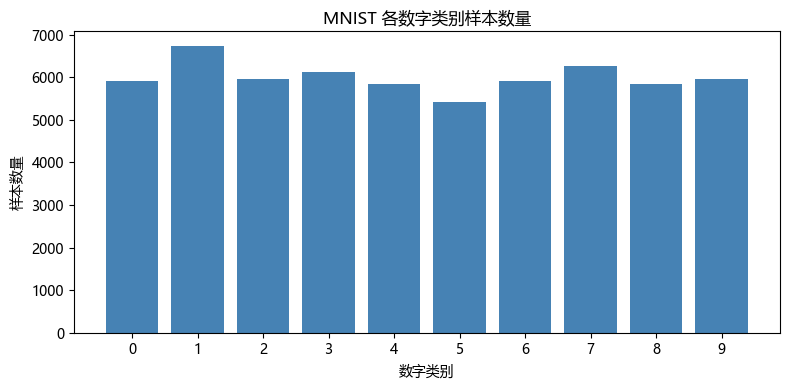

In [4]:
targets = np.array(mnist_dataset.targets)
class_counts = np.bincount(targets, minlength=config.num_classes)
distribution = pd.DataFrame({"数字类别": list(range(config.num_classes)), "样本数量": class_counts})
display(distribution)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(distribution["数字类别"], distribution["样本数量"], color="steelblue")
ax.set_title("MNIST 各数字类别样本数量")
ax.set_xlabel("数字类别")
ax.set_ylabel("样本数量")
ax.set_xticks(range(config.num_classes))
fig.tight_layout()
plt.show()

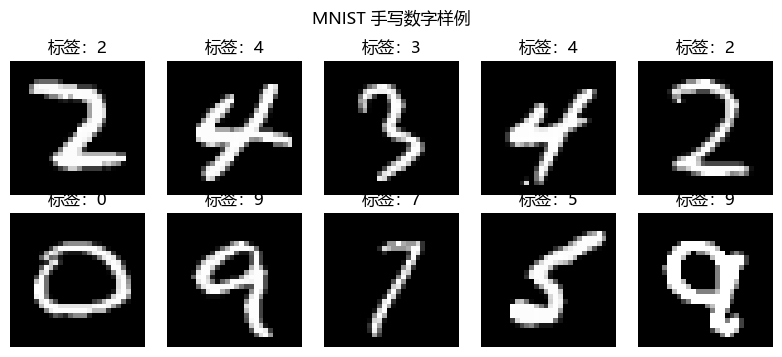

一个 batch 的图片形状：(64, 1, 28, 28)
一个 batch 的标签形状：(64,)


In [5]:
def show_image_grid(dataset, rows: int = 2, cols: int = 5):
    # 反归一化后显示图片，便于人眼观察。
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.8))
    axes = np.array(axes).reshape(rows, cols)
    indices = np.random.default_rng(config.seed).choice(len(dataset), size=rows * cols, replace=False)
    for axis, index in zip(axes.ravel(), indices):
        image, label = dataset[int(index)]
        image = (image * 0.5 + 0.5).clamp(0, 1).squeeze(0).numpy()
        axis.imshow(image, cmap="gray", vmin=0, vmax=1)
        axis.set_title(f"标签：{label}")
        axis.axis("off")
    fig.suptitle("MNIST 手写数字样例")
    fig.tight_layout()
    plt.show()

show_image_grid(mnist_dataset)
batch_images, batch_labels = next(iter(train_loader))
print(f"一个 batch 的图片形状：{tuple(batch_images.shape)}")
print(f"一个 batch 的标签形状：{tuple(batch_labels.shape)}")

## 6. 模型结构：小型 CNN

本作业使用一个小型卷积神经网络：

- 第一层卷积提取低级笔画特征；
- 第二层卷积组合更复杂的局部形状；
- 最大池化降低空间尺寸并增强局部平移鲁棒性；
- 全连接层把图像特征映射到 10 个数字类别。

模型最后输出的是 10 个 logits，不是概率。训练时 `CrossEntropyLoss` 会自动完成 softmax 相关计算。

In [6]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes: int = 10, in_channels: int = 1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.25),
            nn.Linear(128, num_classes),
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        features = self.features(inputs)
        return self.classifier(features)

model = SmallCNN(num_classes=config.num_classes, in_channels=config.in_channels).to(DEVICE)
total_params = sum(parameter.numel() for parameter in model.parameters())
trainable_params = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(model)
print(f"总参数量：{total_params:,}")
print(f"可训练参数量：{trainable_params:,}")

SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
总参数量：421,642
可训练参数量：421,642


In [7]:
model.eval()
with torch.no_grad():
    sample_logits = model(batch_images[:4].to(DEVICE)).cpu()
    sample_probabilities = torch.softmax(sample_logits, dim=1)

print(f"logits 形状：{tuple(sample_logits.shape)}，表示 4 张图片分别对应 10 个类别分数。")
print(f"前 4 张图片真实标签：{batch_labels[:4].tolist()}")
print(f"前 4 张图片预测类别：{sample_probabilities.argmax(dim=1).tolist()}")

logits 形状：(4, 10)，表示 4 张图片分别对应 10 个类别分数。
前 4 张图片真实标签：[8, 6, 5, 8]
前 4 张图片预测类别：[3, 3, 3, 9]


## 7. 训练函数

训练过程每轮包含两个阶段：

1. 在训练集上前向传播、计算损失、反向传播并更新参数；
2. 在验证集上只做前向传播，计算 loss 和 accuracy，用来观察泛化效果。

当验证集准确率刷新最高值时，保存当前模型权重。

In [8]:
def run_epoch(model, loader, criterion, device: str, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = model(images)
            loss = criterion(logits, labels)
            if training:
                loss.backward()
                optimizer.step()

        predictions = logits.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        total_correct += (predictions == labels).sum().item()
        total_examples += images.size(0)

    return {
        "loss": total_loss / total_examples,
        "accuracy": total_correct / total_examples,
    }

def train_model(model, train_loader, val_loader, config: ExperimentConfig):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
    checkpoint_path = CHECKPOINT_DIR / "best_model_state.pt"

    history = {
        "config": config.to_dict(),
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "best_val_accuracy": 0.0,
    }

    best_val_accuracy = -1.0
    for epoch in range(1, config.epochs + 1):
        train_metrics = run_epoch(model, train_loader, criterion, DEVICE, optimizer=optimizer)
        val_metrics = run_epoch(model, val_loader, criterion, DEVICE, optimizer=None)

        history["train_loss"].append(train_metrics["loss"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])

        if val_metrics["accuracy"] > best_val_accuracy:
            best_val_accuracy = val_metrics["accuracy"]
            torch.save(model.state_dict(), checkpoint_path)

        print(
            f"第 {epoch:02d}/{config.epochs} 轮 | "
            f"训练 loss={train_metrics['loss']:.4f}, acc={train_metrics['accuracy']:.4f} | "
            f"验证 loss={val_metrics['loss']:.4f}, acc={val_metrics['accuracy']:.4f}"
        )

    history["best_val_accuracy"] = best_val_accuracy
    (LOG_DIR / "history.json").write_text(json.dumps(history, ensure_ascii=False, indent=2), encoding="utf-8")
    return history, checkpoint_path


## 8. 开始训练模型

默认训练 5 轮。CPU 环境可能需要几分钟；如果只是快速检查流程，可以临时把前面配置中的 `EPOCHS` 改小。正式提交建议保留完整训练结果。

In [9]:
set_seed(config.seed)
model = SmallCNN(num_classes=config.num_classes, in_channels=config.in_channels).to(DEVICE)
history, checkpoint_path = train_model(model, train_loader, val_loader, config)
print(f"最佳验证集准确率：{history['best_val_accuracy']:.4f}")
print(f"最佳模型权重已保存到：{checkpoint_path}")

第 01/5 轮 | 训练 loss=0.2489, acc=0.9224 | 验证 loss=0.0731, acc=0.9775
第 02/5 轮 | 训练 loss=0.0738, acc=0.9780 | 验证 loss=0.0505, acc=0.9853
第 03/5 轮 | 训练 loss=0.0516, acc=0.9845 | 验证 loss=0.0517, acc=0.9848
第 04/5 轮 | 训练 loss=0.0430, acc=0.9867 | 验证 loss=0.0476, acc=0.9862
第 05/5 轮 | 训练 loss=0.0348, acc=0.9894 | 验证 loss=0.0378, acc=0.9902
最佳验证集准确率：0.9902
最佳模型权重已保存到：e:\ALL\学习\AI导论作业-识别手写数字\outputs_submission\checkpoints\best_model_state.pt


## 9. 训练曲线分析

训练曲线可以帮助判断模型是否正常学习：

- 如果训练 loss 持续下降，说明优化过程有效；
- 如果验证 accuracy 同步上升，说明模型学到的特征可以泛化；
- 如果训练准确率很高但验证准确率停滞，可能出现过拟合。

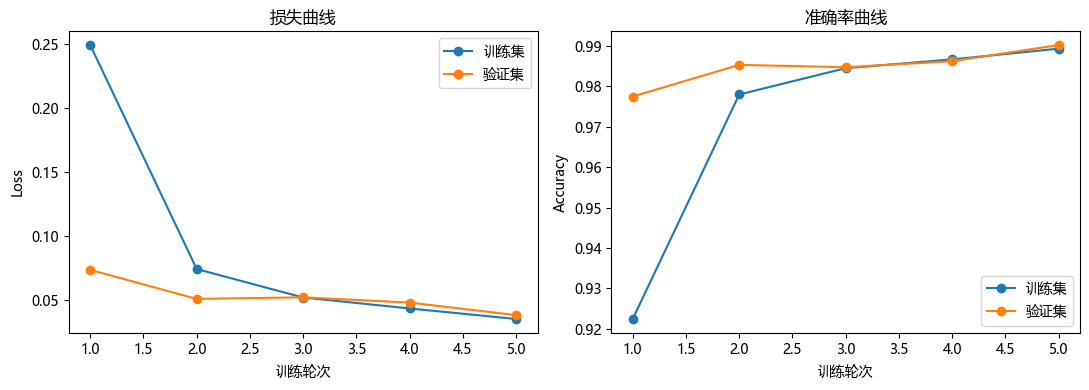

训练曲线已保存到：e:\ALL\学习\AI导论作业-识别手写数字\outputs_submission\figures\training_curves.png


In [10]:
epochs = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs, history["train_loss"], marker="o", label="训练集")
axes[0].plot(epochs, history["val_loss"], marker="o", label="验证集")
axes[0].set_title("损失曲线")
axes[0].set_xlabel("训练轮次")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs, history["train_accuracy"], marker="o", label="训练集")
axes[1].plot(epochs, history["val_accuracy"], marker="o", label="验证集")
axes[1].set_title("准确率曲线")
axes[1].set_xlabel("训练轮次")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

fig.tight_layout()
curve_path = FIGURE_DIR / "training_curves.png"
fig.savefig(curve_path, dpi=160)
plt.show()
print(f"训练曲线已保存到：{curve_path}")

## 10. 验证集评估

下面加载验证集准确率最高的模型权重，在验证集上收集所有预测结果，并计算整体准确率与每个数字类别的 precision、recall、F1-score。

In [11]:
def collect_predictions(model, loader, device: str):
    model.eval()
    image_batches = []
    true_batches = []
    pred_batches = []
    probability_batches = []

    with torch.no_grad():
        for images, labels in loader:
            logits = model(images.to(device))
            probabilities = torch.softmax(logits, dim=1).cpu()
            predictions = probabilities.argmax(dim=1)
            image_batches.append(images.cpu())
            true_batches.append(labels.cpu())
            pred_batches.append(predictions.cpu())
            probability_batches.append(probabilities)

    return (
        torch.cat(image_batches),
        torch.cat(true_batches),
        torch.cat(pred_batches),
        torch.cat(probability_batches),
    )

eval_model = SmallCNN(num_classes=config.num_classes, in_channels=config.in_channels).to(DEVICE)
eval_model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
eval_images, y_true, y_pred, y_prob = collect_predictions(eval_model, val_loader, DEVICE)

accuracy = accuracy_score(y_true.numpy(), y_pred.numpy())
report = classification_report(y_true.numpy(), y_pred.numpy(), digits=4, output_dict=True)
report_df = pd.DataFrame(report).transpose()

summary = {
    "accuracy": float(accuracy),
    "best_val_accuracy": float(history["best_val_accuracy"]),
    "validation_samples": int(len(y_true)),
}
(LOG_DIR / "evaluation_summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"验证集准确率：{accuracy:.4f}")
display(report_df)

验证集准确率：0.9902


,precision,recall,f1-score,support
0,0.989094,0.992424,0.990756,1188.00000
1,0.994842,0.993377,0.994109,1359.00000
2,0.982573,0.989967,0.986256,1196.00000
3,0.992765,0.991968,0.992366,1245.00000
4,0.991364,0.988803,0.990082,1161.00000
5,0.992381,0.989554,0.990965,1053.00000
6,0.993133,0.992281,0.992707,1166.00000
7,0.989860,0.989860,0.989860,1282.00000
8,0.991504,0.991504,0.991504,1177.00000
9,0.984615,0.982097,0.983355,1173.00000


## 11. 混淆矩阵

混淆矩阵用于观察哪些数字容易被混淆。矩阵的行是真实类别，列是预测类别；对角线越明显，说明分类越准确。

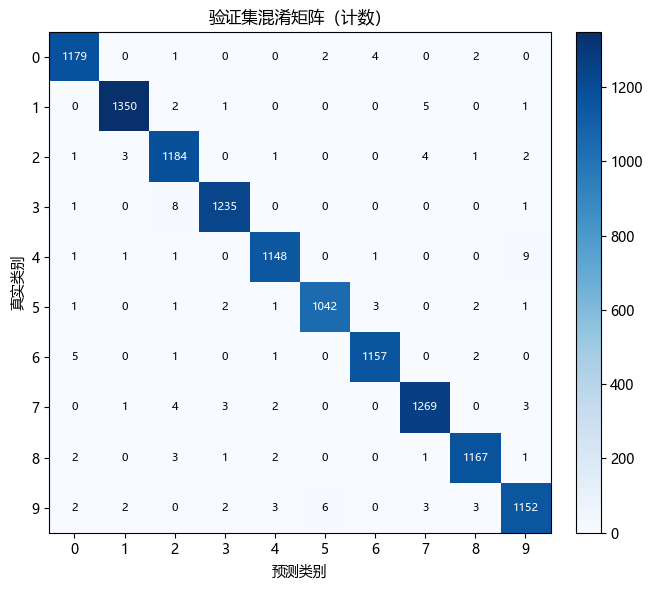

混淆矩阵图片已保存到：e:\ALL\学习\AI导论作业-识别手写数字\outputs_submission\figures\confusion_matrix.png


In [12]:
labels = list(range(config.num_classes))
matrix = confusion_matrix(y_true.numpy(), y_pred.numpy(), labels=labels)
np.savetxt(FIGURE_DIR / "confusion_matrix.csv", matrix, delimiter=",", fmt="%d")

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(matrix, cmap="Blues")
ax.set_title("验证集混淆矩阵（计数）")
ax.set_xlabel("预测类别")
ax.set_ylabel("真实类别")
ax.set_xticks(np.arange(config.num_classes))
ax.set_yticks(np.arange(config.num_classes))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

threshold = matrix.max() / 2.0
for i in range(config.num_classes):
    for j in range(config.num_classes):
        ax.text(
            j,
            i,
            str(int(matrix[i, j])),
            ha="center",
            va="center",
            color="white" if matrix[i, j] > threshold else "black",
            fontsize=8,
        )

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
confusion_path = FIGURE_DIR / "confusion_matrix.png"
fig.savefig(confusion_path, dpi=160)
plt.show()
print(f"混淆矩阵图片已保存到：{confusion_path}")

## 12. 误分类样例分析

只看准确率不够，还需要观察模型错在哪里。下面展示若干个误分类样本，包括真实标签、预测标签和模型对预测类别的置信度。

验证集误分类数量：117 / 12000


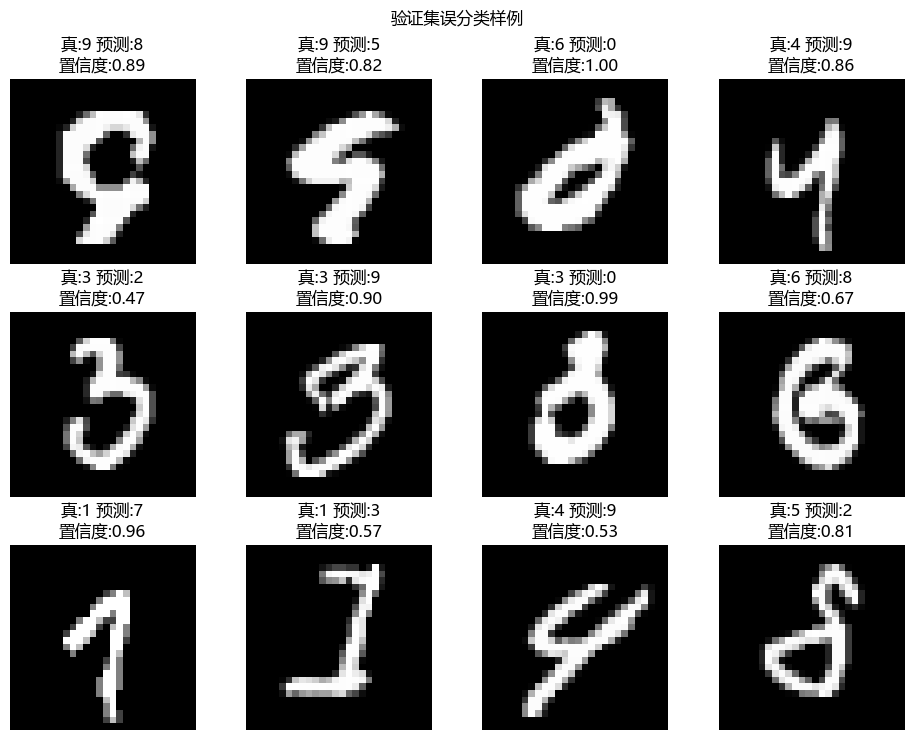

误分类样例图片已保存到：e:\ALL\学习\AI导论作业-识别手写数字\outputs_submission\figures\misclassified_examples.png


In [13]:
wrong_indices = (y_true != y_pred).nonzero(as_tuple=False).flatten().tolist()
print(f"验证集误分类数量：{len(wrong_indices)} / {len(y_true)}")

if wrong_indices:
    sample_count = min(12, len(wrong_indices))
    selected = wrong_indices[:sample_count]
    cols = 4
    rows = int(np.ceil(sample_count / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.4, rows * 2.5))
    axes = np.array(axes).reshape(rows, cols)

    for axis, index in zip(axes.ravel(), selected):
        image = (eval_images[index] * 0.5 + 0.5).clamp(0, 1).squeeze(0).numpy()
        confidence = float(y_prob[index, y_pred[index]])
        axis.imshow(image, cmap="gray", vmin=0, vmax=1)
        axis.set_title(f"真:{int(y_true[index])} 预测:{int(y_pred[index])}\n置信度:{confidence:.2f}")
        axis.axis("off")

    for axis in axes.ravel()[sample_count:]:
        axis.axis("off")

    fig.suptitle("验证集误分类样例")
    fig.tight_layout()
    misclassified_path = FIGURE_DIR / "misclassified_examples.png"
    fig.savefig(misclassified_path, dpi=160)
    plt.show()
    print(f"误分类样例图片已保存到：{misclassified_path}")
else:
    print("验证集没有误分类样本。")

## 13. 导出预测结果

下面把验证集预测结果导出为 CSV，方便检查或作为预测导出格式示例。CSV 使用 `utf-8-sig` 编码，通常可以被 Excel 正确识别中文列名。

如果老师后续提供无标签图片目录，可以使用后面的 `predict_image_folder` 函数生成 `filename,prediction` 格式的预测文件。

In [14]:
validation_predictions = pd.DataFrame({
    "样本序号": np.arange(len(y_true)),
    "真实标签": y_true.numpy(),
    "预测标签": y_pred.numpy(),
    "预测置信度": y_prob.max(dim=1).values.numpy(),
})
validation_csv_path = PREDICTION_DIR / "validation_predictions.csv"
validation_predictions.to_csv(validation_csv_path, index=False, encoding="utf-8-sig")
display(validation_predictions.head())
print(f"验证集预测结果已保存到：{validation_csv_path}")

,样本序号,真实标签,预测标签,预测置信度
0,0,2,2,0.999981
1,1,8,8,1.000000
2,2,7,7,0.999923
3,3,9,9,1.000000
4,4,2,2,1.000000


验证集预测结果已保存到：e:\ALL\学习\AI导论作业-识别手写数字\outputs_submission\predictions\validation_predictions.csv


In [15]:
class ImageFolderForPrediction(Dataset):
    def __init__(self, image_dir: Path, image_size: int = 28):
        self.image_dir = Path(image_dir)
        self.image_paths = sorted(
            path for path in self.image_dir.iterdir()
            if path.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp"}
        )
        if not self.image_paths:
            raise ValueError(f"目录 {self.image_dir} 中没有找到图片文件。")
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        with Image.open(image_path) as image:
            image = image.convert("L")
            tensor = self.transform(image)
        return tensor, image_path.name

def predict_image_folder(image_dir: str | Path, output_csv: str | Path | None = None):
    image_dataset = ImageFolderForPrediction(Path(image_dir), image_size=config.image_size)
    image_loader = DataLoader(image_dataset, batch_size=config.batch_size, shuffle=False, num_workers=0)

    predictor = SmallCNN(num_classes=config.num_classes, in_channels=config.in_channels).to(DEVICE)
    predictor.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    predictor.eval()

    rows = []
    with torch.no_grad():
        for images, filenames in image_loader:
            logits = predictor(images.to(DEVICE))
            probabilities = torch.softmax(logits, dim=1).cpu()
            predictions = probabilities.argmax(dim=1).tolist()
            confidences = probabilities.max(dim=1).values.tolist()
            for filename, prediction, confidence in zip(filenames, predictions, confidences):
                rows.append({"filename": filename, "prediction": prediction, "confidence": confidence})

    if output_csv is None:
        output_csv = PREDICTION_DIR / "unlabeled_predictions.csv"
    output_csv = Path(output_csv)
    pd.DataFrame(rows).to_csv(output_csv, index=False, encoding="utf-8-sig")
    print(f"无标签图片预测结果已保存到：{output_csv}")
    return pd.DataFrame(rows)

# 使用示例：取消下一行注释，并把路径改成老师提供的无标签测试图片目录。
# predict_image_folder("path/to/unlabeled_images")

## 14. 实验结论

本 notebook 完成了手写数字识别的完整流程：

1. 使用 MNIST 数据集构建训练集和验证集；
2. 对灰度图片进行张量化和归一化预处理；
3. 使用两层卷积 + 两层全连接的小型 CNN 学习手写数字特征；
4. 保存验证集表现最好的模型权重；
5. 通过训练曲线、分类报告、混淆矩阵和误分类样例分析模型效果；
6. 提供无标签图片预测函数，便于老师给出测试图片后导出 CSV。

需要注意的是，验证集是从 MNIST 训练集中划分出来的，用来观察模型训练效果和辅助调参。最终成绩应以老师提供的测试集或隐藏测试集为准，不应该用最终测试集反复调参。